## 문제: rk4 방법으로 1차 상미분 방정식 풀기

다음과 같은 1차 상미분 방정식(Ordinary Differential Equation, ODE)이 주어졌을 때,

$$\frac{dy}{dt} = -0.5y$$

초기 조건 $y(0) = 1$ 에서 rk4 방법을 사용하여 $t=0$ 부터 $t=10$ 까지의 시간 범위에서 $y(t)$ 값을 예측하는 코드를 PyTorch로 작성하세요.

**해석적 해:**
이 ODE의 해석적 해는 $y(t) = e^{-0.5t}$ 입니다. 코드에서 Forward Euler 방법으로 얻은 결과와 비교해보세요.

**파라미터:**
*   초기 시간 $t_0 = 0$
*   최종 시간 $t_{end} = 10$
*   시간 간격 $\Delta t = 0.1$
*   초기 조건 $y(0) = 1$
*   상수 $k = 0.5$

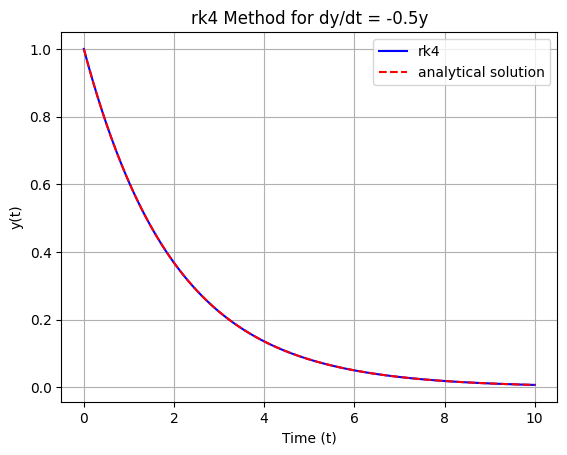

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def ode_function(t, y, k):
  return -k*y

k= 0.5

y0 = torch.tensor(1.0)

t0 = 0; t_end = 10; dt = 0.1
total_step = int((t_end - t0)/dt)

t_current = t0
y_current = y0

t_values = [t0]
y_values = [y0.item()]

for i in range(1, total_step + 1):
  k1 = ode_function(t_current, y_current, k)
  k2 = ode_function(t_current + 0.5*dt, y_current + 0.5*k1*dt, k)
  k3 = ode_function(t_current + 0.5*dt, y_current + 0.5*k2*dt, k)
  k4 = ode_function(t_current + dt, y_current + dt*k3, k)

  y_next = y_current + 1/6*(k1+ 2*k2 + 2*k3+ k4)*dt

  t_next = t_current + dt

  t_values.append(t_next)
  y_values.append(y_next.item())

  t_current = t_next
  y_current = y_next

t_analytical = np.linspace(t0, t_end, 1000)
y_analytical = np.exp(-0.5 * t_analytical)

plt.plot(t_values, y_values, label = 'rk4', color = 'blue', linestyle = '-')
plt.plot(t_analytical, y_analytical, label = 'analytical solution', color = 'red', linestyle='--' )

plt.title('rk4 Method for dy/dt = -0.5y')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.show()




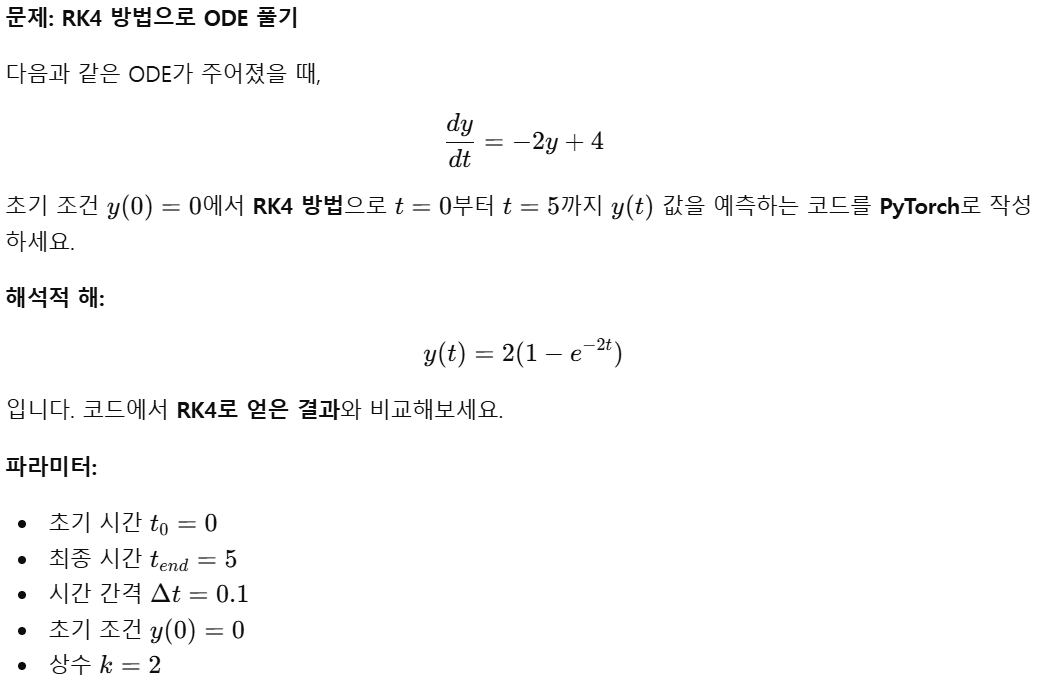

-----step1------
0.1
tensor(0.3625)
-----step2------
0.2
tensor(0.6594)
-----step3------
0.30000000000000004
tensor(0.9024)
-----step4------
0.4
tensor(1.1013)
-----step5------
0.5
tensor(1.2642)
-----step6------
0.6
tensor(1.3976)
-----step7------
0.7
tensor(1.5068)
-----step8------
0.7999999999999999
tensor(1.5962)
-----step9------
0.8999999999999999
tensor(1.6694)
-----step10------
0.9999999999999999
tensor(1.7293)
-----step11------
1.0999999999999999
tensor(1.7784)
-----step12------
1.2
tensor(1.8186)
-----step13------
1.3
tensor(1.8514)
-----step14------
1.4000000000000001
tensor(1.8784)
-----step15------
1.5000000000000002
tensor(1.9004)
-----step16------
1.6000000000000003
tensor(1.9185)
-----step17------
1.7000000000000004
tensor(1.9332)
-----step18------
1.8000000000000005
tensor(1.9453)
-----step19------
1.9000000000000006
tensor(1.9553)
-----step20------
2.0000000000000004
tensor(1.9634)
-----step21------
2.1000000000000005
tensor(1.9700)
-----step22------
2.2000000000000006

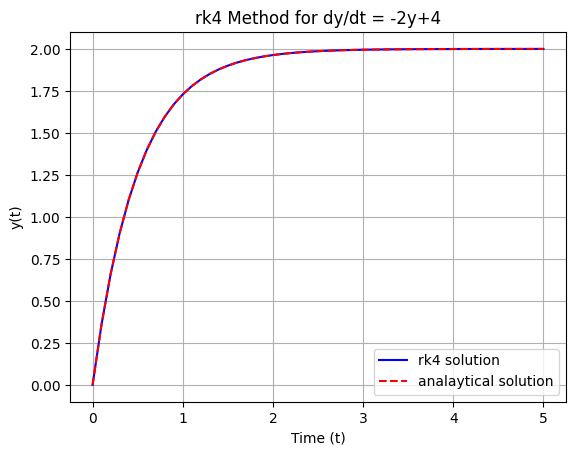

In [26]:
import torch
import matplotlib.pyplot as plt
import numpy as np


def ode_function(t, y, k):
  return -k*y + 4.0


k = 2.0

y0 = torch.tensor(0.0)
t0 = 0.0; t_end = 5.0; dt = 0.1
total_step = int((t_end - t0)/ dt)

t_current = t0
y_current = y0

t_values = [t0]
y_values = [y0.item()]

# print(t_values)
# print(y_values)

for i in range(1, total_step+1):
  print(f"-----step{i}------")
  k1 = ode_function(t_current, y_current, k)
  k2 = ode_function(t_current + 0.5*dt, y_current + 0.5*k1*dt, k)
  k3 = ode_function(t_current + 0.5*dt, y_current + 0.5*k2*dt, k)
  k4 = ode_function(t_current + dt, y_current + k3*dt, k)

  y_next = y_current + 1/6*(k1 + 2*k2 + 2*k3 + k4)*dt

  t_next = t_current + dt

  t_values.append(t_next)
  y_values.append(y_next.item())

  print(t_next)
  print(y_next)
  t_current = t_next
  y_current = y_next



t_analytical = np.linspace(t0, t_end, total_step + 1)
y_analytical = 2*(1- np.exp(-k*t_analytical))

plt.plot(t_values, y_values, label = 'rk4 solution', color = 'blue', linestyle = '-')
plt.plot(t_analytical, y_analytical, label = 'analaytical solution', color = 'red', linestyle = '--')

plt.title('rk4 Method for dy/dt = -2y+4')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.show()

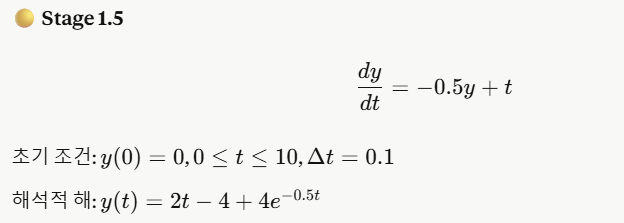

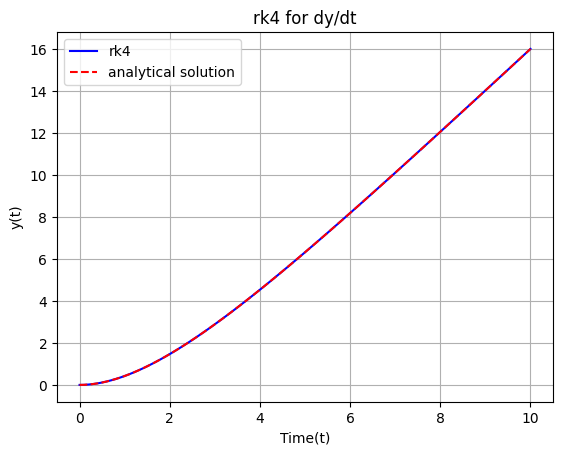

In [36]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def ode_function(t, y, k):
  return -k*y + t

k = 0.5
y0 = torch.tensor(0.0)

t0 = torch.tensor(0.0)
t_end = torch.tensor(10.0)
dt = 0.1
total_step = int((t_end - t0) / dt)

t_current = t0
y_current = y0

t_values = [t0.item()]
y_values = [y0.item()]

for i in range(1, total_step+1):
  k1 = ode_function(t_current, y_current, k)
  k2 = ode_function(t_current + 0.5*dt, y_current + 0.5*k1*dt, k)
  k3 = ode_function(t_current + 0.5*dt, y_current + 0.5*k2*dt, k)
  k4 = ode_function(t_current + dt, y_current + dt*k3, k)

  y_next = y_current + 1/6*(k1 + 2*k2 + 2*k3 + k4)*dt

  t_next = t_current + dt

  t_values.append(t_next.item())
  y_values.append(y_next.item())

  t_current = t_next
  y_current = y_next
t_analytical = np.linspace(t0.item(), t_end.item(), total_step + 1)
y_analytical = 2*t_analytical -4.0 + 4*np.exp(-k*t_analytical)

plt.plot(t_values, y_values, label = 'rk4', color = 'blue', linestyle = '-')
plt.plot(t_analytical, y_analytical, label = 'analytical solution', color = 'red', linestyle = '--')

plt.title('rk4 for dy/dt')
plt.xlabel('Time(t)')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.show()